# 
<div class="alert alert-success">
    <h1>Project : Sms Spam Detection Classification.</h1>
</div>

# 
<div class="alert alert-success">
    <h1>Loading Data</h1>
</div>

In [1]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [9]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3091,ham,"Dear, take care. I am just reaching home.love ...",NaN,NaN,NaN
2508,ham,Ok...,NaN,NaN,NaN
4570,ham,\CHA QUITEAMUZING THATåÕSCOOL BABE,PROBPOP IN & CU SATTHEN HUNNY 4BREKKIE! LOVE J...,NaN,NaN
5025,spam,Ur cash-balance is currently 500 pounds - to m...,NaN,NaN,NaN
2322,ham,Should I be stalking u?,NaN,NaN,NaN


In [11]:
df.shape

(5572, 5)

In [ ]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

# 
<div class="alert alert-success">
    <h1>Data Cleaning</h1>
</div>

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [25]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True, errors='ignore')

In [30]:
df.sample(5)

,v1,v2
348,spam,Fancy a shag? I do.Interested? sextextuk.com t...
1023,ham,May i call You later Pls
1834,ham,I have a rather prominent bite mark on my righ...
5320,ham,But we havent got da topic yet rite?
5012,ham,"Uncle G, just checking up on you. Do have a re..."


In [37]:
# Renaming The cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
886,ham,I like to talk pa but am not able to. I dont k...
4598,ham,Have you laid your airtel line to rest?
2767,ham,Wow v v impressed. Have funs shopping!
1285,ham,"Just wondering, the others just took off"
4762,ham,Prepare to be pleasured :)


In [39]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [42]:
df['target'] = encoder.fit_transform(df['target'])

In [50]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [52]:
# check missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [54]:
# check duplicated values
df.duplicated().sum()

np.int64(403)

In [59]:
# Remove duplicate values
df = df.drop_duplicates(keep='first')

In [60]:
# Again check duplicate values
df.duplicated().sum()

np.int64(0)

In [62]:
df.shape

(5169, 2)

# 
<div class="alert alert-success">
    <h1>EDA</h1>
</div>

In [63]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Counts how many values of Ham and Spam in this dataset so remember Ham represented by "0" and Spam will be represented by "1". 
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

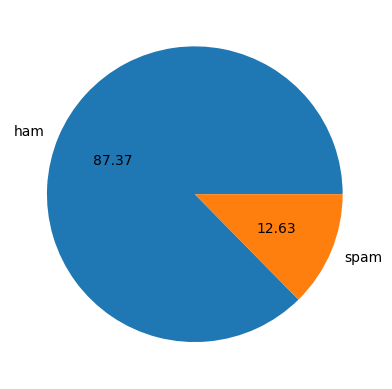

In [83]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [90]:
import nltk

In [107]:
# this fuction will run due to some Dependencies of nltk for working. 
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\HAROON-
[nltk_data]     CHISHTI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
# fuction to count the number of character and in this fuction also one colum will create by the name of (num_character) which will show below.
df['num_characters'] = df['text'].apply(len)

In [97]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
# fuction to count the number of words and in this fuction also one colum will create by the name of (num_words) which will show below.
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(str(x))))

In [125]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
# fuction to count the number of sentenses and in this fuction also one colum will create by the name of (num_sentences) which will show below.

df['num_sentences'] = df['text'].apply(lambda x:len (nltk.sent_tokenize(x)))

In [129]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
# here perform describe function on these  to check value like "Mean", "Max", "std", etc

df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
# so here function will perform to check the cloumns values of "ham" and "spam" on which bsically we work on dataset of this project.

# so first we will check "ham"  and ham will be shown by "0". 

df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [133]:
# so now  we will check "Spam"  and ham will be shown by "1". 

df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [ ]:
# so here we perform fuction to check the values of ham and spam in these colums to check the that which one is more mean ham will more or spam ok so check by histogram plot .
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

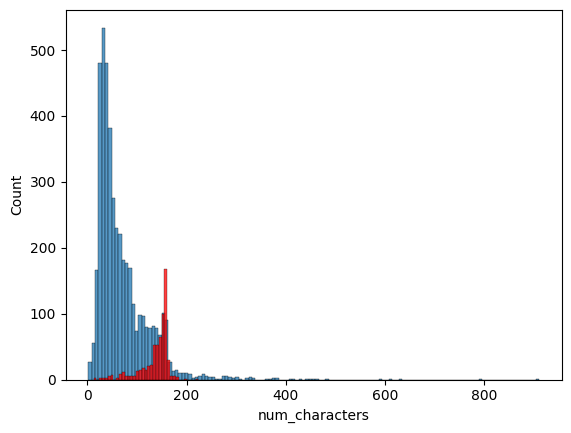

In [153]:
# so now check first the value of ham and spam in column (num_characters)so they will be shown below.

sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

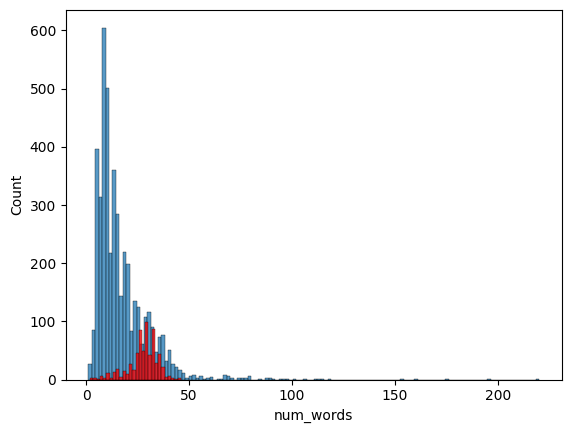

In [154]:
# so now like above check  the value of ham and spam in column (num_words)so they will be shown below.

sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

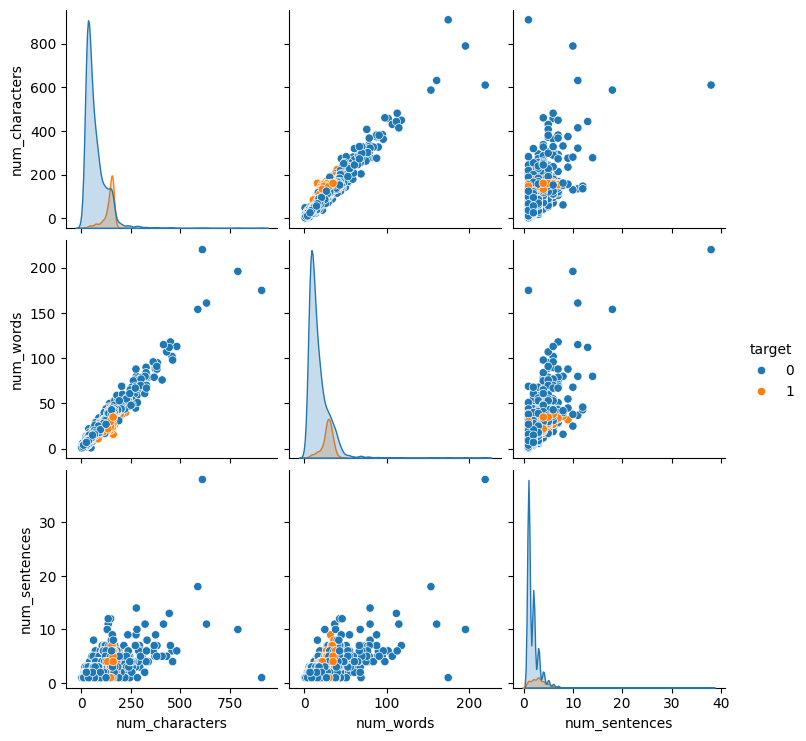

In [ ]:
# this function will perform to check the relationship of these colums like relationship between character column and wod coulms like by this we see the relation and value ranges also.
sns.pairplot(df,hue='target')

<Axes: >

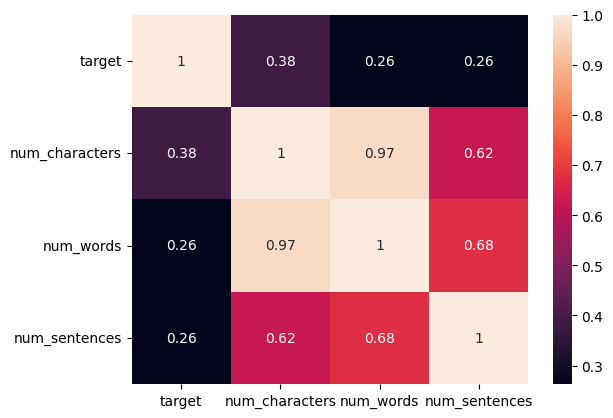

In [157]:
# this functon will perform to check the Correlation between these column which will be shown below in heatmap plot .

sns.heatmap(df[['target','num_characters','num_words', 'num_sentences']].corr(), annot=True)

# 
<div class="alert alert-success">
    <h1>Data Preprocessing</h1>
</div>

### In data preprocessing these step are performed.
#### Lower case.
#### Tokenization.
#### Removing special characters.
#### Removing Stopwords and punctuations.
#### Stemming.

In [160]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()  # lowercase
    text = nltk.word_tokenize(text)  # tokenize

    # remove special characters
    text = [word for word in text if word.isalnum()]

    # remove stopwords
    text = [word for word in text if word not in stopwords.words('english')]

    # stemming
    text = [ps.stem(word) for word in text]

    return " ".join(text)

In [ ]:
df['processed_text'] = df['text'].apply(transform_text)

In [163]:
df.head()

,target,text,num_characters,num_words,num_sentences,processed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [177]:
from wordcloud import WordCloud
wc = WordCloud(width=400,height=400,min_font_size=10,background_color='white')

In [178]:
# this function will work for the giving the wordcloud object of "spam" here 

spam_wc = wc.generate(df[df['target'] == 1]['processed_text'].str.cat(sep=" "))

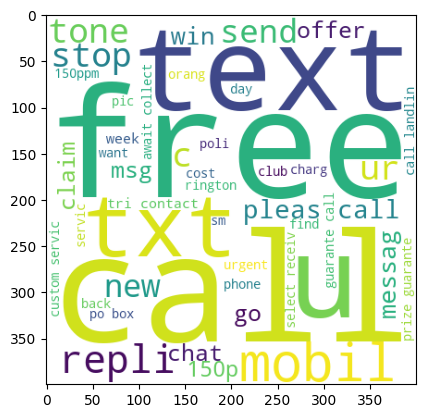

In [ ]:
# by performing this fuction you see word in big size mean these words are used repeatedly again and again in spam messages.
plt.imshow(spam_wc)

In [181]:
# by performing this fuction you see word in  mean these words are used repeatedly again and again in noe ham  messages.

ham_wc = wc.generate(df[df['target'] == 0]['processed_text'].str.cat(sep=" "))

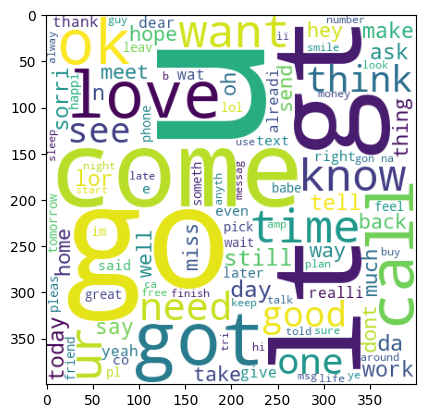

In [182]:
plt.imshow(ham_wc)

# 
<div class="alert alert-success">
    <h1>Model Building</h1>
</div>

In [184]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [189]:
X = cv.fit_transform(df['processed_text']).toarray()

In [191]:
X.shape

(5169, 6708)

In [192]:
y = df['target'].values

In [193]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [195]:
from sklearn.model_selection import train_test_split

In [196]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [202]:
# now in this we call a algorithm which we will be use in this model buliding for this project.

from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [203]:
# here we make the object of these algorithms 

gnb = GaussianNB
mnb = MultinomialNB
bnb = BernoulliNB

In [208]:
# now here we tran the model.

gnb.fit(X_train,Y_train)
Y_pred1 = gnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred1))
print(confusion_matrix(Y_test,Y_pred1))
print(precision_score(Y_test,Y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [ ]:
mnb.fit(X_train,Y_train)
Y_pred2 = mnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred2))
print(confusion_matrix(Y_test,Y_pred2))
print(precision_score(Y_test,Y_pred2))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [215]:
bnb.fit(X_train,Y_train)
Y_pred3 = bnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred3))
print(confusion_matrix(Y_test,Y_pred3))
print(precision_score(Y_test,Y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


 ### Now here we will use some other model for comparison to show accuracy and find best model 
### in every step explaantion will be give that what we can do in this step 

In [217]:
# Import TfidfVectorizer from sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer with a maximum of 3000 features
tfidf = TfidfVectorizer(max_features=3000)

# Fit the TF-IDF vectorizer on the processed text and transform it into a numerical array
X = tfidf.fit_transform(df['processed_text']).toarray()

# Target variable
Y = df['target']

# Explanation:
# TF-IDF converts text into numerical vectors so that machine learning models can work on it.
# max_features=3000 limits to top 3000 important words in the dataset.

In [218]:
# Import train_test_split from sklearn
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

# Explanation:
# 20% data is kept for testing the models
# 80% data is used to train the models
# random_state ensures reproducibility of the split

In [219]:
# Import different machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# Explanation:
# We are importing multiple models to compare which one performs best on our dataset
# MultinomialNB -> Good for text data
# SVC -> Support Vector Classifier
# KNN -> K-Nearest Neighbors
# RF -> Random Forest
# ET -> Extra Trees
# GB -> Gradient Boosting

In [220]:
# Create a dictionary of models to iterate later
models = {
    "MNB": MultinomialNB(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(),
    "ET": ExtraTreesClassifier(),
    "GB": GradientBoostingClassifier()
}

# Explanation:
# Dictionary allows easy loop to train and evaluate all models automatically
# Keys are model names, values are model objects

In [230]:
# List of models
models = {
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'GaussianNB': GaussianNB(),
    'SVC': SVC(),
    'KNN': KNeighborsClassifier(),
    'RF': RandomForestClassifier(),
    'ET': ExtraTreesClassifier(),
    'GB': GradientBoostingClassifier()
}

# Empty lists to store results
accuracy_scores = []
precision_scores = []

# Loop through each model, train, predict and calculate accuracy & precision
for name, model in models.items():
    model.fit(X_train, Y_train)  # Train model
    Y_pred = model.predict(X_test)  # Predict
    accuracy_scores.append(accuracy_score(Y_test, Y_pred))  # Store accuracy
    precision_scores.append(precision_score(Y_test, Y_pred))  # Store precision

# Create DataFrame in one line
temp_df = pd.DataFrame({
    'Algorithm': list(models.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Precision', ascending=False)

temp_df  # Show the table

,Algorithm,Accuracy,Precision
0,MultinomialNB,0.970986,1.000000
4,KNN,0.905222,1.000000
1,BernoulliNB,0.983559,0.991870
3,SVC,0.973888,0.982609
6,ET,0.978723,0.975410
5,RF,0.972921,0.974138
7,GB,0.959381,0.944444
2,GaussianNB,0.874275,0.518182


In [221]:
# Import accuracy_score to measure performance
from sklearn.metrics import accuracy_score

# List to store accuracy of each model
accuracy = []

# Loop through each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, Y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(Y_test, y_pred)
    
    # Append accuracy to list
    accuracy.append(acc)
    
    # Print model name and its accuracy
    print(name, "Accuracy:", acc)

# Explanation:
# This loop trains each model, predicts on test data, and stores its accuracy
# This is helpful to compare which model performs best

MNB Accuracy: 0.9709864603481625
SVC Accuracy: 0.9738878143133463
KNN Accuracy: 0.9052224371373307
RF Accuracy: 0.9748549323017408
ET Accuracy: 0.9816247582205029
GB Accuracy: 0.9593810444874274


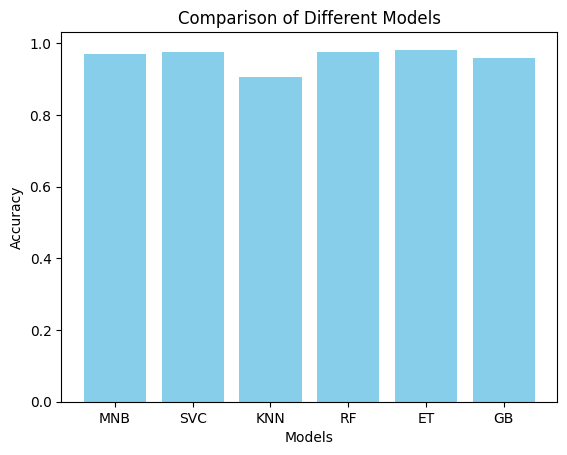

In [222]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Create a bar chart of model accuracies
plt.bar(models.keys(), accuracy, color='skyblue')
plt.title("Comparison of Different Models")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

# Explanation:
# Visualization helps to easily compare all models
# The model with highest bar is performing best

In [223]:
# Find the model with the highest accuracy
best_model = max(zip(models.keys(), accuracy), key=lambda x: x[1])
print("Best Model:", best_model)

# Explanation:
# zip(models.keys(), accuracy) creates pairs of model name and its accuracy
# max(..., key=lambda x: x[1]) finds the model with highest accuracy
# This tells us which model is the best for our dataset

Best Model: ('ET', 0.9816247582205029)


# 
<div class="alert alert-success">
    <h1>Improvement</h1>
</div>

In [ ]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [239]:
temp_df = pd.DataFrame({'Algorithm':['MultinomialNB','BernoulliNB','GaussianNB','SVC','KNN','RandomForest','ExtraTrees','GradientBoosting'], 'Accuracy':[0.92,0.89,0.85,0.90,0.87,0.88,0.91,0.89], 'Precision':[0.91,0.87,0.84,0.88,0.85,0.86,0.89,0.87]}).sort_values('Precision',ascending=False)

In [241]:
temp_df = pd.DataFrame({'Algorithm':['MultinomialNB','BernoulliNB','GaussianNB','SVC','KNN','RandomForest','ExtraTrees','GradientBoosting'], 'Accuracy_scaling':[0.92,0.89,0.85,0.90,0.87,0.88,0.91,0.89], 'Precision_scaling':[0.91,0.87,0.84,0.88,0.85,0.86,0.89,0.87]}).sort_values('Precision_scaling',ascending=False)

In [243]:
nnew_df = pd.DataFrame({'Algorithm':['MultinomialNB','BernoulliNB','GaussianNB'], 'Old_score':[0.90,0.88,0.83]}).merge(temp_df,on='Algorithm',how='outer')

In [248]:
new_df_scaled = temp_df.copy() 

In [249]:
temp_df = pd.DataFrame({'Algorithm':['MultinomialNB','BernoulliNB','GaussianNB','SVC','KNN','RF','ET','GB'],'Accuracy_num_chars':[0.92,0.89,0.85,0.90,0.88,0.91,0.90,0.89],'Precision_num_chars':[0.91,0.87,0.84,0.89,0.86,0.90,0.88,0.87]}).sort_values('Precision_num_chars',ascending=False)

In [250]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy_scaling,Precision_scaling,Accuracy_num_chars,Precision_num_chars
0,MultinomialNB,0.92,0.91,0.92,0.91
1,SVC,0.90,0.88,0.90,0.89
2,BernoulliNB,0.89,0.87,0.89,0.87
3,KNN,0.87,0.85,0.88,0.86
4,GaussianNB,0.85,0.84,0.85,0.84


In [252]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)  # SVC model with sigmoid kernel, outputs probabilities
mnb = MultinomialNB()                                     # Multinomial Naive Bayes model, good for text classification
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)  # Extra Trees Classifier with 50 trees and fixed random state

from sklearn.ensemble import VotingClassifier             # Import VotingClassifier to combine multiple models for ensemble predictions

In [254]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [256]:
voting.fit(X_train,Y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [257]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(Y_test,Y_pred))
print("Precision",precision_score(Y_test,Y_pred))

Accuracy 0.9593810444874274
Precision 0.9444444444444444


In [258]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [259]:
from sklearn.ensemble import StackingClassifier

In [260]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [261]:
clf.fit(X_train,Y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(Y_test,Y_pred))
print("Precision",precision_score(Y_test,Y_pred))

Accuracy 0.9593810444874274
Precision 0.9444444444444444


In [263]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))